### Preparing training data from clustered images

In [129]:
#load bounding_box_infos.json
import json
from itertools import islice

with open('bounding_box_infos.json', 'r') as f:
    bounding_box_infos = json.load(f)
# print("Sample bounding box infos:")
# for key, value in islice(bounding_box_infos.items(), 3):
#     print(f"\t{key, value}")

In [130]:
#load clusters from all_clusters.json
with open('all_clusters.json', 'r') as f:
    all_clusters = json.load(f)
#print sample clusters
# print("Sample clusters:")
# for key, value in islice(all_clusters.items(), 3):
#     print(f"\t{key}: {value}")

In [117]:
import pandas as pd
#iterate through dates, which are keys in all_clusters
training_data_centers = {}
training_data_bboxes = {}

training_df = pd.DataFrame()
training_df_rows = []

for date, clusters in all_clusters.items():
    print(f"Processing date: {date} with {len(clusters)} clusters")
    
    #get all images for this date
    date_images = [img for img in bounding_box_infos.keys() if img.startswith(date)]
    training_data_centers[date] = {}
    training_data_bboxes[date] = {}
    
    print(f"\tFound {len(date_images)} images for this date.")
    for cluster_number in clusters.keys():
        cluster_data = clusters[cluster_number]
        cluster_center = cluster_data['center']
        cluster_x = round(float(cluster_center[0]))
        cluster_y = round(float(cluster_center[1]))
        cluster_key_repr = f"({cluster_x},{cluster_y})"
        
        cluster_width = 0 #to fill in
        cluster_height = 0 #to fill in
        
        for img in date_images:
            # Ensure dictionaries are only initialized once per image
            if img not in training_data_centers[date]:
                training_data_centers[date][img] = {}
            if img not in training_data_bboxes[date]:
                training_data_bboxes[date][img] = {}
            
            bbox_info = bounding_box_infos[img]
            found = False
            for bbox in bbox_info:
                #print(f"\t\t\tChecking bbox: {bbox}")
                bbox_center_x = round(float(bbox['center_x']))
                bbox_center_y = round(float(bbox['center_y']))
                bbox_width = round(float(bbox['width']))
                bbox_height = round(float(bbox['height']))
                
                #Check if bbox center is within cluster center +/- half width/height
                if (cluster_x - bbox_width / 2 <= bbox_center_x <= cluster_x + bbox_width / 2 and
                    cluster_y - bbox_height / 2 <= bbox_center_y <= cluster_y + bbox_height / 2):
                    #print(f"\t\tMatch found in image {img}")
                    #this should have the label 1 in training data
                    training_data_centers[date][img][cluster_key_repr] = 1
                    #print(" - Match found, labeled 1")
                    found = True
                    cluster_width = bbox_width
                    cluster_height = bbox_height
                    break #no need to check other bboxes in this image
            if not found:
                training_data_centers[date][img][cluster_key_repr] = 0
                
        #See if cluster has ever been found
        if cluster_width == 0 or cluster_height == 0:
            print(f"\tWarning: Cluster {cluster_number} at {cluster_key_repr} was never matched in any image.")
        else:
            #We have cluster dimensions, reformat cluster key to be [x_min, y_min, x_max, y_max]
            x_min = int(cluster_x - cluster_width / 2)
            y_min = int(cluster_y - cluster_height / 2)
            x_max = int(cluster_x + cluster_width / 2)
            y_max = int(cluster_y + cluster_height / 2)
            new_cluster_key_repr = f"[{x_min},{y_min},{x_max},{y_max}]"
            #print(f"\tCluster {cluster_number} key reformatted from {cluster_key_repr} to {new_cluster_key_repr}")
            #Update training data keys
            for date in training_data_centers.keys():
                for img in training_data_centers[date].keys():
                    if cluster_key_repr in training_data_centers[date][img].keys():
                        training_data_bboxes[date][img][new_cluster_key_repr] = training_data_centers[date][img][cluster_key_repr]
    
    #Save data to row for dataframe
    #Date, number of images, number of clusters, number of 1's, number of 0's
    num_ones = sum(1 for img_data in training_data_bboxes[date].values() for label in img_data.values() if label == 1)
    num_zeros = sum(1 for img_data in training_data_bboxes[date].values() for label in img_data.values() if label == 0)
    training_df_row = [date, len(date_images), len(clusters), num_ones, num_zeros]
    training_df_rows.append(training_df_row)
    
training_df = pd.DataFrame(training_df_rows, columns=['date', 'num_images', 'num_clusters', 'num_ones', 'num_zeros'])


Processing date: 2013-02-22 with 53 clusters
	Found 154 images for this date.
Processing date: 2013-04-08 with 4 clusters
	Found 4 images for this date.
Processing date: 2013-03-13 with 45 clusters
	Found 137 images for this date.
Processing date: 2013-03-19 with 32 clusters
	Found 33 images for this date.
Processing date: 2013-03-18 with 49 clusters
	Found 135 images for this date.
Processing date: 2013-03-03 with 0 clusters
	Found 33 images for this date.
Processing date: 2013-04-09 with 26 clusters
	Found 33 images for this date.
Processing date: 2013-03-22 with 19 clusters
	Found 29 images for this date.
Processing date: 2013-03-14 with 40 clusters
	Found 108 images for this date.
Processing date: 2013-03-10 with 0 clusters
	Found 125 images for this date.
Processing date: 2013-03-21 with 38 clusters
	Found 66 images for this date.
Processing date: 2013-04-13 with 6 clusters
	Found 58 images for this date.
Processing date: 2013-02-23 with 8 clusters
	Found 26 images for this date.


In [118]:
training_df

,date,num_images,num_clusters,num_ones,num_zeros
0,2013-02-22,154,53,5317,2845
1,2013-04-08,4,4,16,0
2,2013-03-13,137,45,5063,1102
3,2013-03-19,33,32,641,415
4,2013-03-18,135,49,4673,1942
5,2013-03-03,33,0,0,0
6,2013-04-09,33,26,597,261
7,2013-03-22,29,19,279,272
8,2013-03-14,108,40,3017,1303
9,2013-03-10,125,0,0,0


In [112]:
# Rearrange training_data_bboxes to have image names as top-level keys
rearranged_bboxes = {}

for date, images in training_data_bboxes.items():
    for image_name, bboxes in images.items():
        if image_name not in rearranged_bboxes:
            rearranged_bboxes[image_name] = {}
        for bbox_key, label in bboxes.items():
            rearranged_bboxes[image_name][bbox_key] = label

In [121]:
from PIL import Image
import os

# Directory to save cropped images
output_dir = "label_verification"
os.makedirs(output_dir, exist_ok=True)

# Process the first image in the dictionary
for image_name, bboxes in list(rearranged_bboxes.items())[17:18]:  # Change the slice to process different images
    print(f"Processing image: {image_name}")
    
    # Create a subdirectory for the image
    image_dir = os.path.join(output_dir, os.path.splitext(image_name)[0])  # Remove the extension
    os.makedirs(image_dir, exist_ok=True)
    
    # Open the image
    image_path = os.path.join("aligned_images/ufpr05_template_matching", image_name)  # Replace "path_to_images" with the actual path
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Image {image_name} not found at {image_path}. Skipping.")
        continue

    # Iterate through bounding boxes
    for bbox, label in bboxes.items():
        # Parse the bounding box coordinates
        x1, y1, x2, y2 = map(int, bbox.strip("[]").split(","))
        
        # Crop the image
        cropped_img = img.crop((x1, y1, x2, y2))
        
        # Create label-specific subdirectory within the image directory
        label_dir = os.path.join(image_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)
        
        # Save the cropped image
        cropped_image_name = f"{x1}_{y1}_{x2}_{y2}.jpg"
        cropped_image_path = os.path.join(label_dir, cropped_image_name)
        cropped_img.save(cropped_image_path)
        #print(f"Saved cropped image to {cropped_image_path}")

Processing image: 2013-02-22_07_35_01.jpg


### Visualization

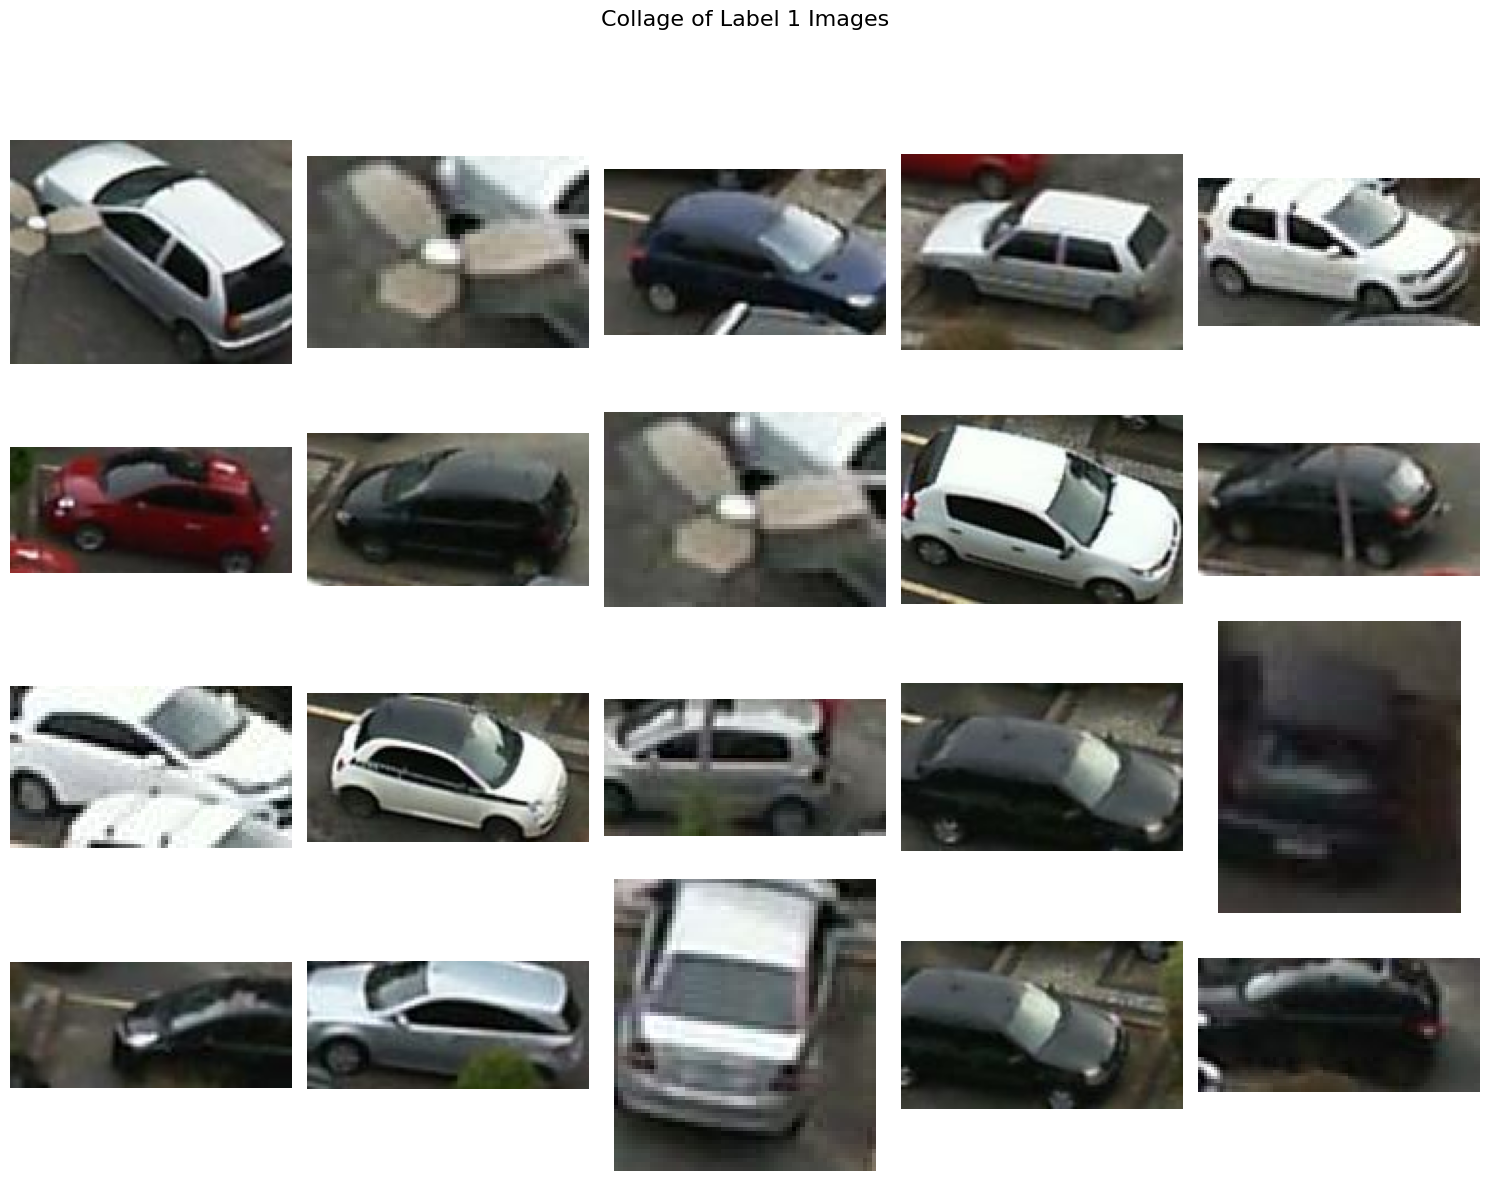

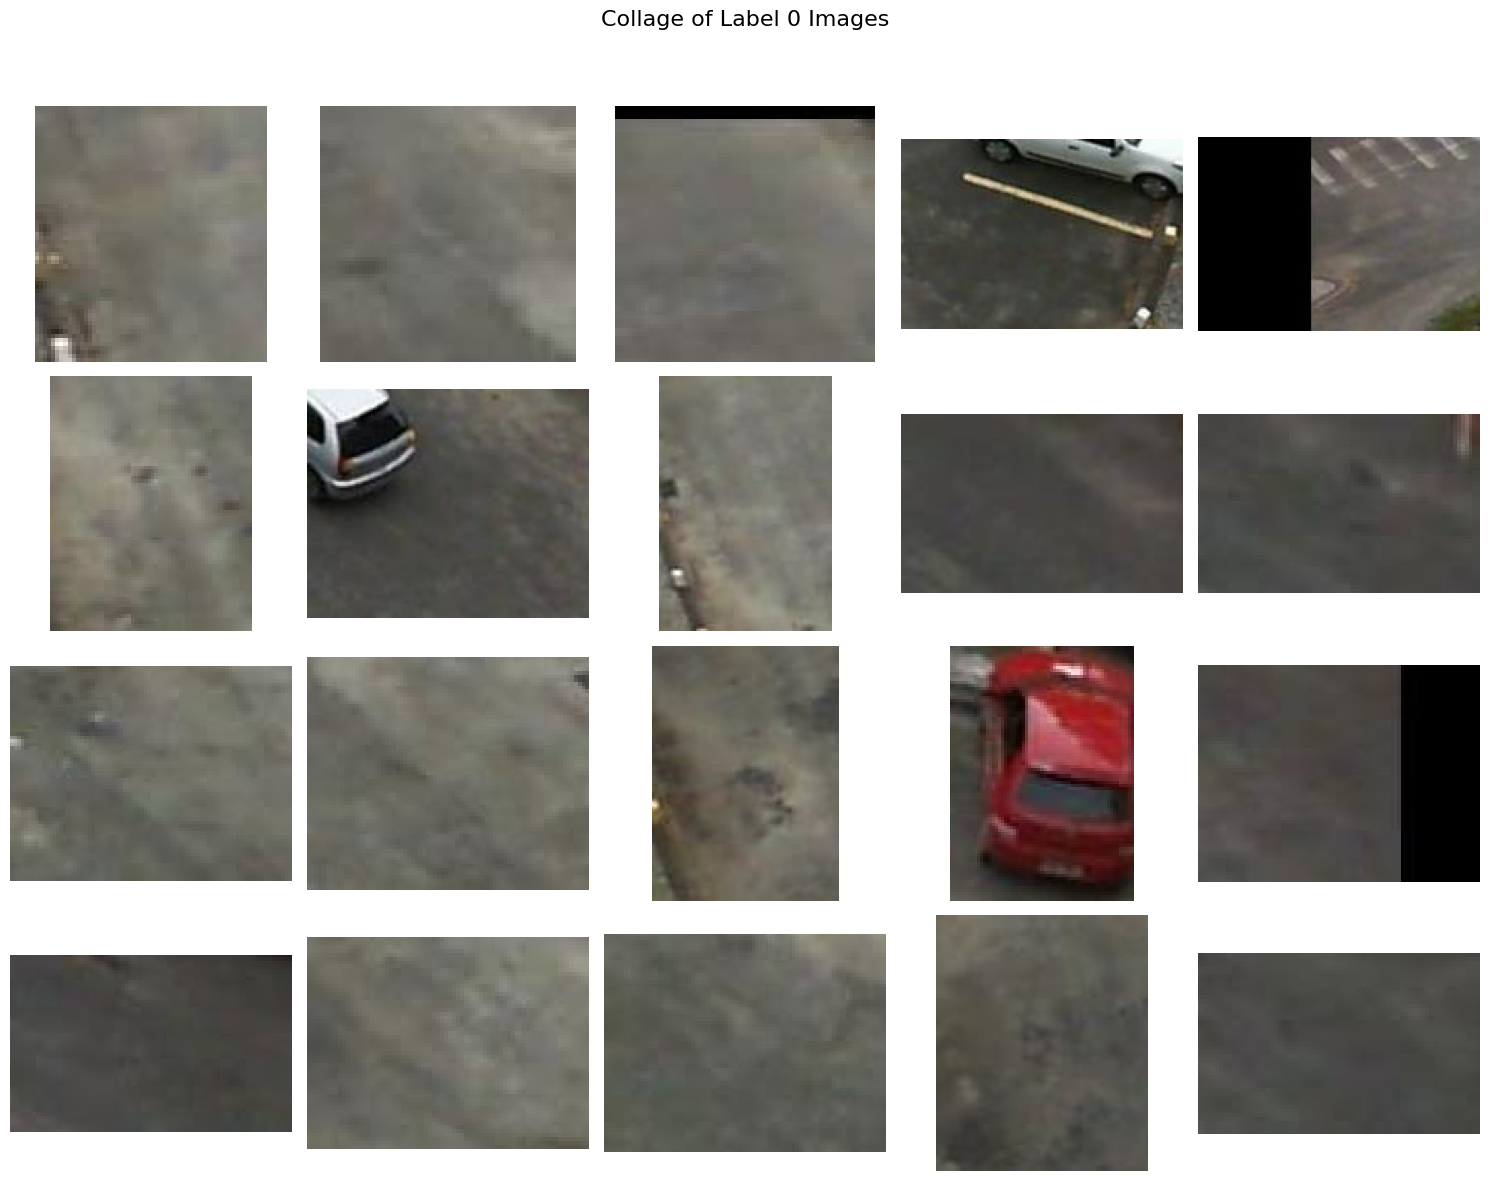

In [125]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Directories for ones and zeros
collage_ones_dir = "label_verification/2013-02-22_07_35_01/1"
collage_zeros_dir = "label_verification/2013-02-22_07_35_01/0"

# Function to create a collage
def create_collage(image_dir, title, rows=4, cols=5):
    # Get all image file paths in the directory
    image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    # Limit to the number of slots in the collage
    image_files = image_files[:rows * cols]
    
    # Create a figure for the collage
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # Iterate through the grid and add images
    for i, ax in enumerate(axes.flat):
        if i < len(image_files):
            img = Image.open(image_files[i])
            ax.imshow(img)
            ax.axis('off')  # Turn off axes for a cleaner look
        else:
            ax.axis('off')  # Turn off unused slots
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust title position
    plt.show()

# Create collages for ones and zeros
create_collage(collage_ones_dir, "Collage of Label 1 Images")
create_collage(collage_zeros_dir, "Collage of Label 0 Images")

### Save to output file

In [128]:
import json
#save rearranged_bboxes
with open('label_verification/cluster_training.json', 'w') as f:
    json.dump(rearranged_bboxes, f, indent=4)